In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np

In [45]:
NUM_SAMPLES = 5000
samples = ch.randn(NUM_SAMPLES, 1)

class TruncatedProbitMLE(ch.autograd.Function): 
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=NUM_SAMPLES, eps=1e-5): 
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """
        stacked = pred[None,...].repeat(num_samples, 1, 1)
        rand_noise = ch.randn(stacked.size())
        noised = stacked + rand_noise 
        noised_labs = noised >= 0
        mask = noised_labs.eq(targ)
        filtered = phi(noised)
    
        mle = (filtered * mask).sum(0)
        trunc_const = (filtered).sum(0)

        ctx.save_for_backward(rand_noise, filtered, mask)
        ctx.eps = eps
        return -ch.log(mle/trunc_const) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output): 
        rand_noise, filtered, mask = ctx.saved_tensors
        nll = (mask * filtered * rand_noise).sum(dim=0) / ((mask * filtered).sum(dim=0) + ctx.eps)
        const = (rand_noise * filtered).sum(dim=0) / (filtered.sum(dim=0) + ctx.eps)
        return -(nll - const) / rand_noise.size(1), None, None, None, None

In [46]:
def trunc_probit_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    pred.requires_grad = True
    loss = TruncatedProbitMLE.apply(pred, targ, phi)
    loss = loss.sum(0)
#     print(f'summed loss: {loss}')
    loss.backward()
    return loss, pred.grad

In [47]:
import statsmodels.api as smf 

W = .5*ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + ch.randn(X.size(0))

Y = (Z > 0).int()

prob_reg = smf.Probit(Y.numpy(), X.numpy())
results = prob_reg.fit()

gt_w = ch.from_numpy(results.params)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([0.5000])
ground truth num samples: 1000
Optimization terminated successfully.
         Current function value: 0.672813
         Iterations 4
fitted w: tensor([0.4418], dtype=torch.float64)


In [48]:
prob_reg.predict(results.params, X) > 0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [49]:
def phi(z): 
    return z > -.5

trunc_indices = phi(Z).nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = (Z_trunc > 0).int()
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_prob_reg = smf.Probit(Y_trunc.numpy(), X_trunc.numpy())
trunc_results = trunc_prob_reg.fit()

trunc_w = ch.from_numpy(trunc_results.params)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.764
Optimization terminated successfully.
         Current function value: 0.556622
         Iterations 5
trunc fitted w: tensor([1.2105], dtype=torch.float64)


<IPython.core.display.Javascript object>


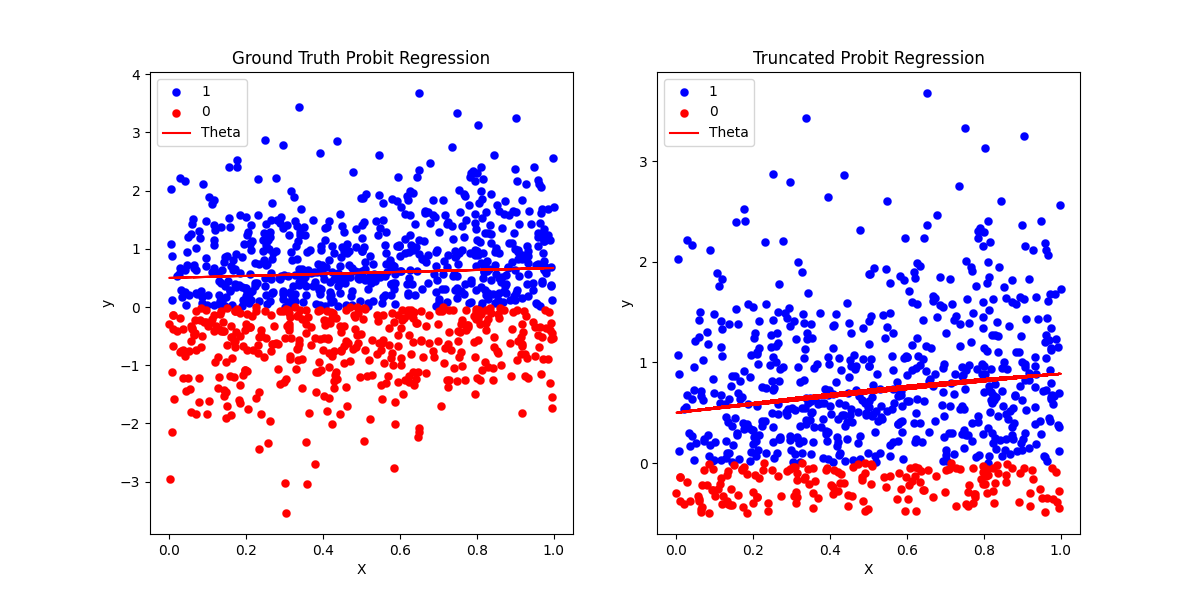

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.nonzero()
zeros = (~Y.bool()).nonzero()
ax1.scatter(X[ones], Z[ones], linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z[zeros], linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = results.predict(X_sorted)
ax1.plot(X_sorted, pred, color='red', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Probit Regression')
ax1.legend()

trunc_ones = Y_trunc.nonzero()
trunc_zeros = (~Y_trunc.bool()).nonzero()
ax2.scatter(X_trunc[trunc_ones], Z_trunc[trunc_ones], linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc[trunc_zeros], linewidths=.1, color='red', label='0')
trunc_pred = trunc_results.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='red', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.set_title('Truncated Probit Regression')
ax2.legend()
plt.show()

# Vary w

<IPython.core.display.Javascript object>


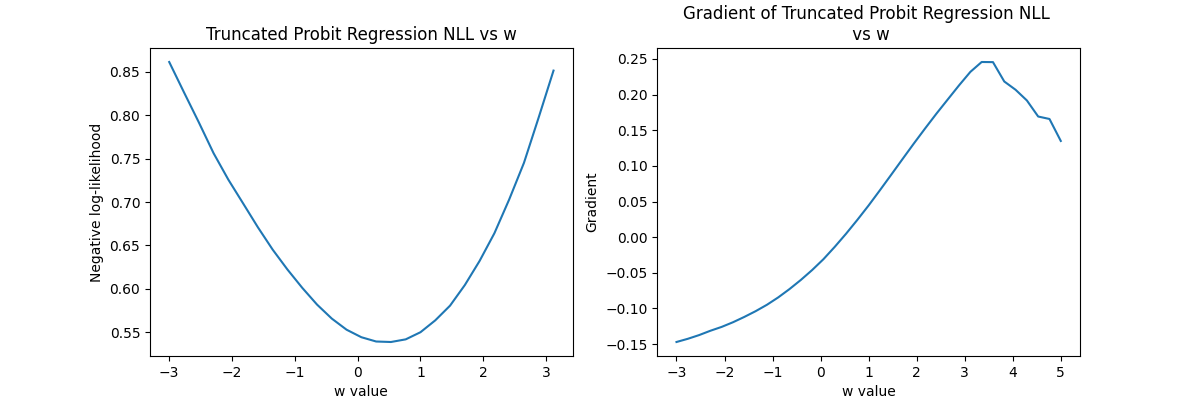

In [52]:
ws = ch.linspace(-3, 5, 35)

losses = ch.Tensor([])
grads = ch.Tensor([])

for w in ws: 
    loss, pred_grad = trunc_probit_mle(X_trunc @ w.reshape(1, 1), Y_trunc[...,None], phi)
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses)
ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Probit Regression NLL vs w")

ax2.plot(ws, grads)
ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Probit Regression NLL \n vs w")

plt.show()

In [53]:
ws[losses.argmin()], ws

(tensor(0.5294),
 tensor([-3.0000, -2.7647, -2.5294, -2.2941, -2.0588, -1.8235, -1.5882, -1.3529,
         -1.1176, -0.8824, -0.6471, -0.4118, -0.1765,  0.0588,  0.2941,  0.5294,
          0.7647,  1.0000,  1.2353,  1.4706,  1.7059,  1.9412,  2.1765,  2.4118,
          2.6471,  2.8824,  3.1176,  3.3529,  3.5882,  3.8235,  4.0588,  4.2941,
          4.5294,  4.7647,  5.0000]))

# Truncated Probit Regression with Bias

In [23]:
from statsmodels.tools.tools import add_constant

W = .5*ch.ones(1)
W0 = .5*ch.ones(1)
print(f'groud truth W:\n {W}')
print(f'ground truth bias:\n {W0}')

X = ch.rand(1000, 1)
X_ones = add_constant(X.numpy())
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + W0 + ch.randn(X.size(0))

Y = (Z > 0).int()

prob_reg = smf.Probit(Y.numpy(), X_ones)
results = prob_reg.fit()

gt_w = ch.from_numpy(results.params)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([0.5000])
ground truth bias:
 tensor([0.5000])
ground truth num samples: 1000
Optimization terminated successfully.
         Current function value: 0.553852
         Iterations 5
fitted w: tensor([0.5074, 0.3630], dtype=torch.float64)


In [24]:
def phi(z): 
    return z > -.25

trunc_indices = phi(Z).nonzero().flatten()
X_trunc, Z_trunc = ch.from_numpy(X_ones)[trunc_indices].float(), Z[trunc_indices]
Y_trunc = (Z_trunc > 0).int()
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_prob_reg = smf.Probit(Y_trunc.numpy(), X_trunc.numpy())
trunc_results = trunc_prob_reg.fit()

trunc_w = ch.from_numpy(trunc_results.params)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.827
Optimization terminated successfully.
         Current function value: 0.295580
         Iterations 6
trunc fitted w: tensor([1.3129, 0.0887], dtype=torch.float64)


/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_10512/2010705110.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  Z[i, j] = loss


Ground truth: w=0.507, w0=0.363
Minimum found: w=0.534, w0=0.328, loss=0.296

Loss at ground truth: 0.296
Loss at minimum: 0.296
Difference: 0.000


/tmp/ipykernel_10512/2010705110.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gt_loss = trunc_probit_mle((X_trunc @ results.params)[...,None], Y_trunc[...,None], phi)[0].item()


<IPython.core.display.Javascript object>


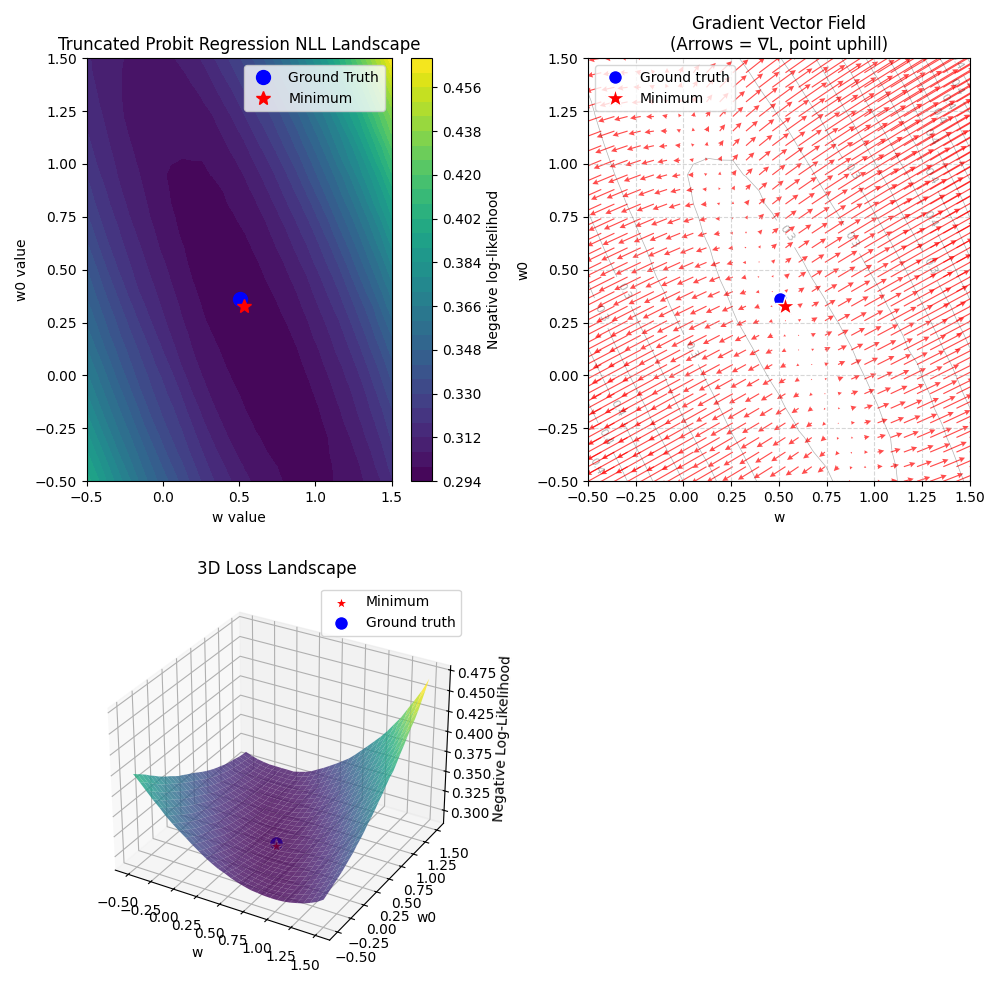

In [25]:
# === Parameter grids ===
W_values = ch.linspace(-.5, 1.5, 30)
W0_values = ch.linspace(-.5, 1.5, 30)
W_, W0_ = ch.meshgrid(W_values, W0_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_W0 = ch.zeros_like(W0_)
for i in range(len(W_values)):
    for j in range(len(W0_values)):
        w = ch.cat([W_[i, j][...,None], W0_[i, j][...,None]])[...,None]
        trunc_pred = X_trunc @ w
        loss, pred_grad = trunc_probit_mle(trunc_pred, Y_trunc[...,None], phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_[min_idx], W0_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={results.params[0].item():.3f}, w0={results.params[1].item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_probit_mle((X_trunc @ results.params)[...,None], Y_trunc[...,None], phi)[0].item()

print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

In [26]:
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Probit Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(results.params[0], results.params[1], 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(results.params[0], results.params[1], 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('w0')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, W0_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [W0_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([results.params[0]], [results.params[1]], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('w0')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_10512/3241619495.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(GRAD_W), GRAD_W.shape)


tensor(-0.5000)

In [27]:
import torch.nn.functional as F

In [28]:
r = ch.from_numpy(results.params).float()[None,...]
trunc_r = ch.from_numpy(trunc_results.params).float()[None,...]
trunc_cosine = F.cosine_similarity(r, trunc_r)
print(f'trunc cosine similarity: {trunc_cosine}')
w_min = ch.cat([W_min[None,...], W0_min[None,...]])[None,...]
delphi_cosine = F.cosine_similarity(r, w_min)
print(f'delphi cosine similarity: {delphi_cosine}')

trunc cosine similarity: tensor([0.8506])
delphi cosine similarity: tensor([0.9975])


# Truncated Probit Regression with Two Weight and No Bias

In [29]:
from statsmodels.tools.tools import add_constant

W = ch.ones(2, 1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 2)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + ch.randn(X.size(0), 1)

Y = (Z > 0).int()

prob_reg = smf.Probit(Y.numpy(), X.numpy())
results = prob_reg.fit()

gt_w = ch.from_numpy(results.params)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 1000
Optimization terminated successfully.
         Current function value: 0.448224
         Iterations 5
fitted w: tensor([1.0803, 0.8525], dtype=torch.float64)


In [31]:
def phi(z): 
    return z > -.25

trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices].float(), Z[trunc_indices]
Y_trunc = (Z_trunc > 0).int()
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_prob_reg = smf.Probit(Y_trunc.numpy(), X_trunc.numpy())
trunc_results = trunc_prob_reg.fit()

trunc_w = ch.from_numpy(trunc_results.params)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.881
Optimization terminated successfully.
         Current function value: 0.266028
         Iterations 6
trunc fitted w: tensor([1.6550, 1.3167], dtype=torch.float64)


In [34]:
# === Parameter grids ===
W1_values = ch.linspace(-.5, 1.5, 20)
W2_values = ch.linspace(-.5, 1.5, 20)
W1_, W2_ = ch.meshgrid(W1_values, W2_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(W1_)
GRAD_W1 = ch.zeros_like(W1_)
GRAD_W2 = ch.zeros_like(W2_)
for i in range(len(W1_values)):
    for j in range(len(W2_values)):
        w = ch.cat([W1_[i, j][...,None], W2_[i, j][...,None]])[...,None]
        trunc_pred = X_trunc @ w
        loss, pred_grad = trunc_probit_mle(trunc_pred, Y_trunc, phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W1[i, j] = grad_[0]
        GRAD_W2[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W1_min, W2_min = W1_[min_idx], W2_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w1={results.params[0].item():.3f}, w2={results.params[1].item():.3f}")
print(f"Minimum found: w1={W1_min:.3f}, w2={W2_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_probit_mle((X_trunc @ results.params)[...,None], Y_trunc, phi)[0].item()

print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

Ground truth: w1=1.080, w2=0.853
Minimum found: w1=1.079, w2=0.658, loss=0.247

Loss at ground truth: 0.247
Loss at minimum: 0.247
Difference: 0.001


/tmp/ipykernel_10512/3821186375.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gt_loss = trunc_probit_mle((X_trunc @ results.params)[...,None], Y_trunc, phi)[0].item()


<IPython.core.display.Javascript object>


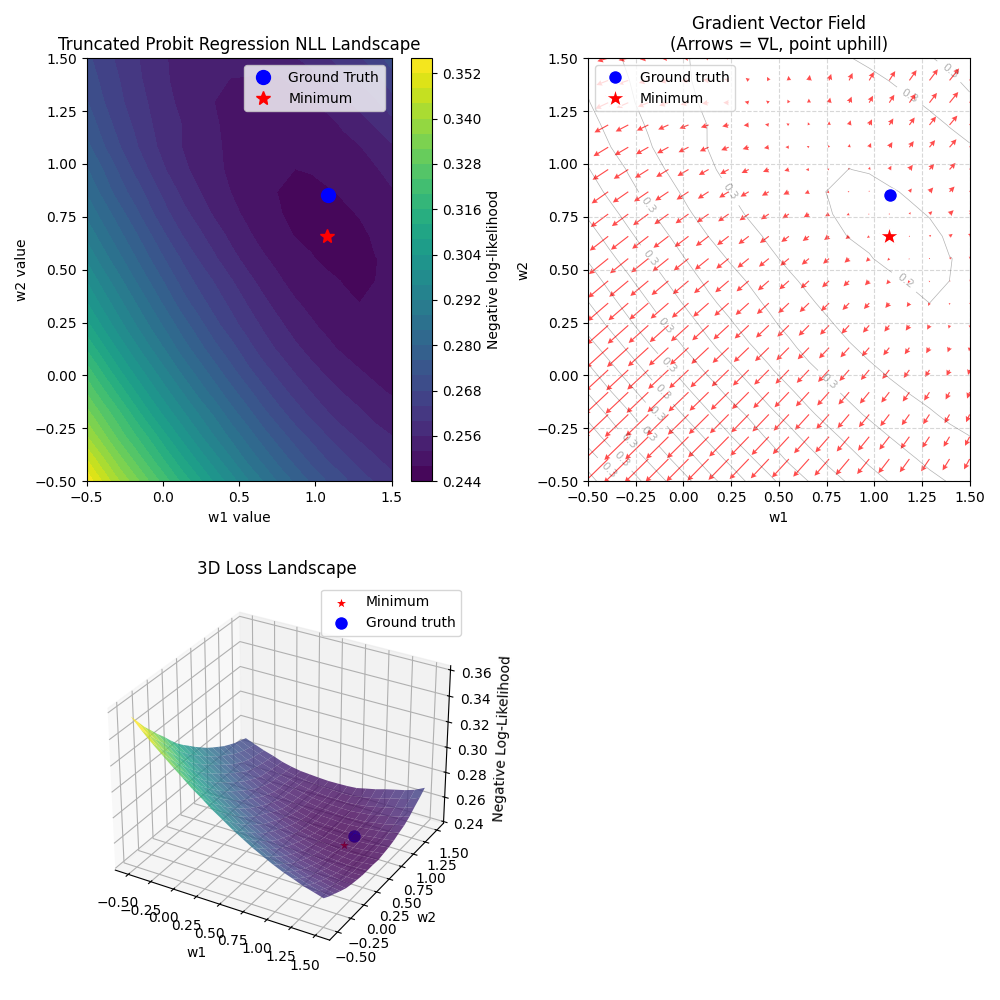

In [35]:
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W1_, W2_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Probit Regression NLL Landscape")
ax1.set_xlabel("w1 value")
ax1.set_ylabel("w2 value")

# mark the ground truth
ax1.plot(results.params[0], results.params[1], 'bo', markersize=10, label="Ground Truth")
ax1.plot(W1_min.item(), W2_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W1_, W2_, GRAD_W1, GRAD_W2,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W1_, W2_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(results.params[0], results.params[1], 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W1_min, W2_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W1_, W2_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W1_min], [W2_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([results.params[0]], [results.params[1]], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w1')
ax3.set_ylabel('w2')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [36]:
r = ch.from_numpy(results.params).float()[None,...]
trunc_r = ch.from_numpy(trunc_results.params).float()[None,...]
trunc_cosine = F.cosine_similarity(r, trunc_r)
print(f'trunc cosine similarity: {trunc_cosine}')
w_min = ch.cat([W1_min[None,...], W2_min[None,...]])[None,...]
delphi_cosine = F.cosine_similarity(r, w_min)
print(f'delphi cosine similarity: {delphi_cosine}')

trunc cosine similarity: tensor([1.0000])
delphi cosine similarity: tensor([0.9927])


In [38]:
trunc_r

tensor([[1.6550, 1.3167]])

In [39]:
w_min

tensor([[1.0789, 0.6579]])